# Power Grid Cascading Failures as Percolation
## ESAM395: Simple Discrete Models - Project 2

This script simulates cascading failures in power grids modeled as a 2D lattice
where transmission lines have finite capacity and failures propagate through
load redistribution.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import time

## Helper Functions

In [2]:
def create_grid(L):
    """
    Create LxL grid graph with positions.

    Inputs:
    - L: Number of Nodes on each side of the square lattice.
    Outputs: 
    - G(networkx.graph): Undirected grid graph with L^2 nodes arranged in a square lattice.
    - pos(dict): Dictionary mapping each node (i, j) to its position (i, j),
        used in drawing functions.
    """
    G = nx.grid_2d_graph(L, L)
    pos = {node: node for node in G.nodes()}
    return G, pos

def initialize_grid(G, tolerance):
    """
    Assign loads and capacities to edges.
    
    Inputs:
    - tolerance: capacity = (1+τ) x initial_load
    - G(networkx.graph): Input graph to recieve edge attributes.
    Outputs: 
    - G(networkx.graph): Output graph complete with load and capacity edge attributes.
    """
    for edge in G.edges():
        load = np.random.normal(1,0.15)
        G.edges[edge]['load'] = load
        G.edges[edge]['capacity'] = (1 + tolerance) * load
    return G

def redistribute_load_simple(G, failed_edges):
    """
    For each failed edge (u, v), its load is redistributed equally among
    the remaining edges incident to nodes u and v. Failed edges themselves
    receive no redistributed load.

    Inputs:
    - G(networkx.graph): Original Graph containing edge load attributes.
    - failed_edges: collection of edges considered faulted and removed.
    Outputs:
    - new_loads(dict): Dictionary Mapping surviving edges to updated load values after redistribution.
    """
    new_loads = {edge: G.edges[edge]['load'] for edge in G.edges() 
                 if edge not in failed_edges}
    
    G_work = G.copy()
    G_work.remove_edges_from(failed_edges)
    
    for u, v in failed_edges:
        failed_load = G.edges[(u, v)]['load']
        
        # Get neighbors
        neighbors_u = list(G_work.neighbors(u))
        neighbors_v = list(G_work.neighbors(v))
        
        # Collect edges to redistribute to
        redistrib_edges = []
        for n in neighbors_u:
            e = (u, n) if (u, n) in new_loads else (n, u)
            if e in new_loads:
                redistrib_edges.append(e)
        for n in neighbors_v:
            e = (v, n) if (v, n) in new_loads else (n, v)
            if e in new_loads and e not in redistrib_edges:
                redistrib_edges.append(e)
        
        # Distribute load
        if redistrib_edges:
            extra = failed_load / len(redistrib_edges)
            for e in redistrib_edges:
                new_loads[e] += extra
    
    return new_loads

def simulate_cascade(G, initial_failure, max_iter=100):
    """
    Run cascade simulation until equilibrium.

    Inputs:
    - G: Initial weighted graph
    - initial_failure: edge that starts the cascade
    - max_iter: maximum number of redistribution iterations allowed
    Outputs: 
    - results(dict): Dictionary containing cascade data and statistics after equilibrium reached.
    """
    failed = set([initial_failure])
    
    for iteration in range(max_iter):
        # Redistribute loads
        new_loads = redistribute_load_simple(G, failed)
        
        # Find new failures
        newly_failed = set()
        for edge, load in new_loads.items():
            if load > G.edges[edge]['capacity']:
                newly_failed.add(edge)
        
        if not newly_failed:
            break
        
        failed.update(newly_failed)
    
    # Calculate final statistics
    G_final = G.copy()
    G_final.remove_edges_from(failed)
    
    if G_final.number_of_nodes() > 0:
        components = list(nx.connected_components(G_final))
        giant = max(components, key=len) if components else set()
        S = len(giant) / G.number_of_nodes()
    else:
        S = 0
    
    return {
        'cascade_size': len(failed),
        'giant_fraction': S,
        'survival_prob': 1 - len(failed) / G.number_of_edges(),
        'iterations': iteration + 1
    }

## Run Simulations

In [3]:
def run_simulations(L, tolerances, n_trials):
    """Run simulations across tolerance values."""
    results = defaultdict(list)
    
    print(f"Running simulations for L={L}...")
    
    for i, tau in enumerate(tolerances):
        print(f"  [{i+1}/{len(tolerances)}] τ = {tau:.3f}...", end=" ")
        
        for trial in range(n_trials):
            # Create and initialize grid
            G, pos = create_grid(L)
            G = initialize_grid(G, tau)
            
            # Random initial failure
            edges = list(G.edges())
            initial = edges[np.random.randint(len(edges))]
            
            # Run cascade
            result = simulate_cascade(G, initial)
            
            results[tau].append(result)
        
        # Calculate statistics
        S_mean = np.mean([r['giant_fraction'] for r in results[tau]])
        print(f"S={S_mean:.3f}")
    
    return results

## Display Results

In [4]:
def plot_all_results(all_results):
    """Create all plots as separate figures."""

    # Plot 1
    plt.figure(figsize=(8, 6))
    ax1 = plt.gca()

    for L, results in sorted(all_results.items()):
        tolerances = sorted(results.keys())
        means = [np.mean([r['survival_prob'] for r in results[t]]) 
                 for t in tolerances]
        
        ax1.plot(tolerances, means, marker='o', linewidth=2, label=f'L={L}')
    
    ax1.set_xscale('log')
    ax1.axvline(0.5927, color='red', linestyle='--', linewidth=2,
                label='2D percolation P_c', alpha=0.7)
    ax1.axvline(0.42, color='#800000', linestyle='--', linewidth=2,
                label='Proposed Model P_c', alpha=0.7)
    ax1.set_xlabel('Tolerance τ', fontsize=12)
    ax1.set_ylabel('Edge Survival Probability', fontsize=12)
    ax1.set_title('Edge Survival Probability vs Tolerance', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    # Plot 2
    plt.figure(figsize=(8, 6))
    ax2 = plt.gca()

    for L, results in sorted(all_results.items()):
        tolerances = sorted(results.keys())
        means = [np.mean([r['cascade_size'] for r in results[t]]) 
                 for t in tolerances]
        
        ax2.plot(tolerances, means, marker='o', linewidth=2, label=f'L={L}')
        
    ax2.axvline(0.5927, color='red', linestyle='--', linewidth=2,
                label='2D percolation P_c', alpha=0.7)
    ax2.axvline(0.42, color='#800000', linestyle='--', linewidth=2,
                label='Proposed Model P_c', alpha=0.7)
    ax2.set_xscale('log')
    ax2.set_xlabel('Tolerance τ', fontsize=12)
    ax2.set_ylabel('Average Cascade Size', fontsize=12)
    ax2.set_title('Cascade Sizes', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_example_cascade(L=12, tolerance=0.2):
    """Help to visualize a single cascade progression."""
    
    G, pos = create_grid(L)
    G = initialize_grid(G, tolerance)
    
    # Choose central edge to fail
    center_node = (L//2, L//2)
    edges = list(G.edges())
    initial = None
    for edge in edges:
        if center_node in edge:
            initial = edge
            break
    if initial is None:
        initial = edges[len(edges)//2]
    
    # Simulate cascade step by step
    failed = set([initial])
    states = [failed.copy()]
    
    for _ in range(10):  
        new_loads = redistribute_load_simple(G, failed)
        newly_failed = set()
        for edge, load in new_loads.items():
            if load > G.edges[edge]['capacity']:
                newly_failed.add(edge)
        
        if not newly_failed:
            break
        
        failed.update(newly_failed)
        states.append(failed.copy())
    
    # Plot only 3 states for example
    n_states = min(3, len(states))
    indices = [0, len(states)//2, -1][:n_states]
    
    fig, axes = plt.subplots(1, n_states, figsize=(5*n_states, 5))
    if n_states == 1:
        axes = [axes]
    
    for i, idx in enumerate(indices):
        state = states[idx]
        G_temp = G.copy()
        G_temp.remove_edges_from(state)
        
        axes[i].set_title(f'Step {idx}: {len(state)} failures', 
                         fontsize=13, fontweight='bold')
        nx.draw(G_temp, pos, ax=axes[i], node_size=15, 
                node_color='lightblue', edge_color='gray', width=0.8)
        axes[i].axis('off')
    
    plt.suptitle(f'Cascade Progression Example (L={L}, τ={tolerance})', 
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Main

POWER GRID CASCADING FAILURES

Grid sizes: [12, 20, 30]
Tolerance points: 21
Trials per point: 15
Total simulations: 945

Running simulations for L=12...
  [1/21] τ = 0.100... S=0.007
  [2/21] τ = 0.130... S=0.007
  [3/21] τ = 0.160... S=0.073
  [4/21] τ = 0.190... S=0.338
  [5/21] τ = 0.220... S=0.338
  [6/21] τ = 0.250... S=0.669
  [7/21] τ = 0.280... S=1.000
  [8/21] τ = 0.310... S=0.868
  [9/21] τ = 0.340... S=1.000
  [10/21] τ = 0.370... S=1.000
  [11/21] τ = 0.400... S=1.000
  [12/21] τ = 0.430... S=1.000
  [13/21] τ = 0.460... S=1.000
  [14/21] τ = 0.490... S=1.000
  [15/21] τ = 0.520... S=1.000
  [16/21] τ = 0.550... S=1.000
  [17/21] τ = 0.580... S=1.000
  [18/21] τ = 0.610... S=1.000
  [19/21] τ = 0.640... S=1.000
  [20/21] τ = 0.670... S=1.000
  [21/21] τ = 0.700... S=1.000

Time for L=12: 3.11 seconds
Running simulations for L=20...
  [1/21] τ = 0.100... S=0.003
  [2/21] τ = 0.130... S=0.003
  [3/21] τ = 0.160... S=0.069
  [4/21] τ = 0.190... S=0.335
  [5/21] τ = 0.220... S

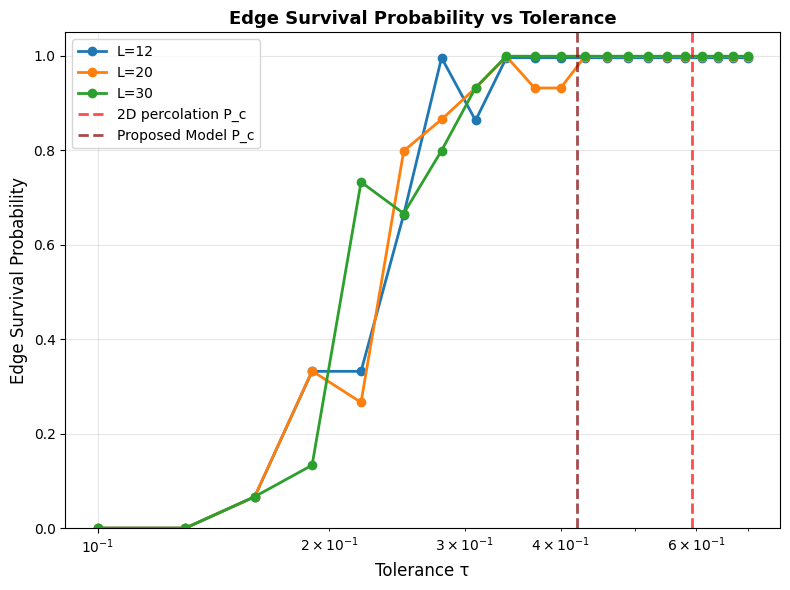

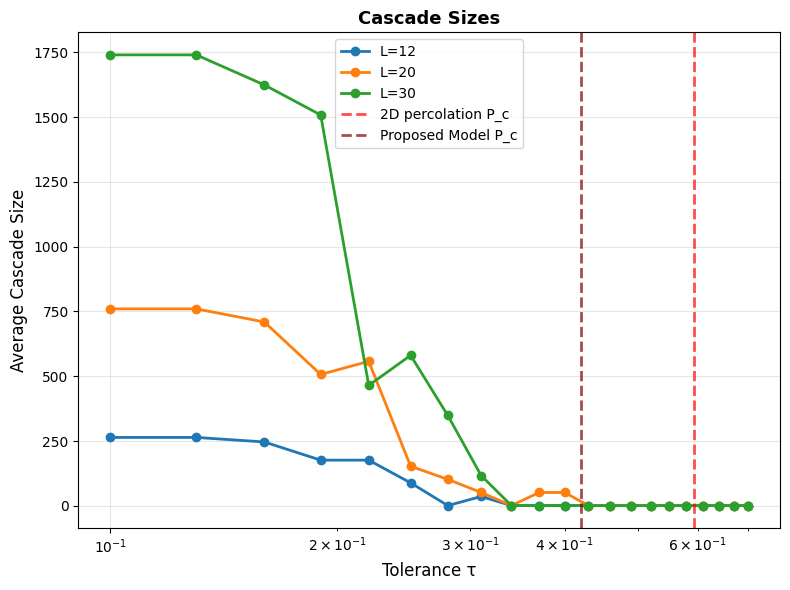

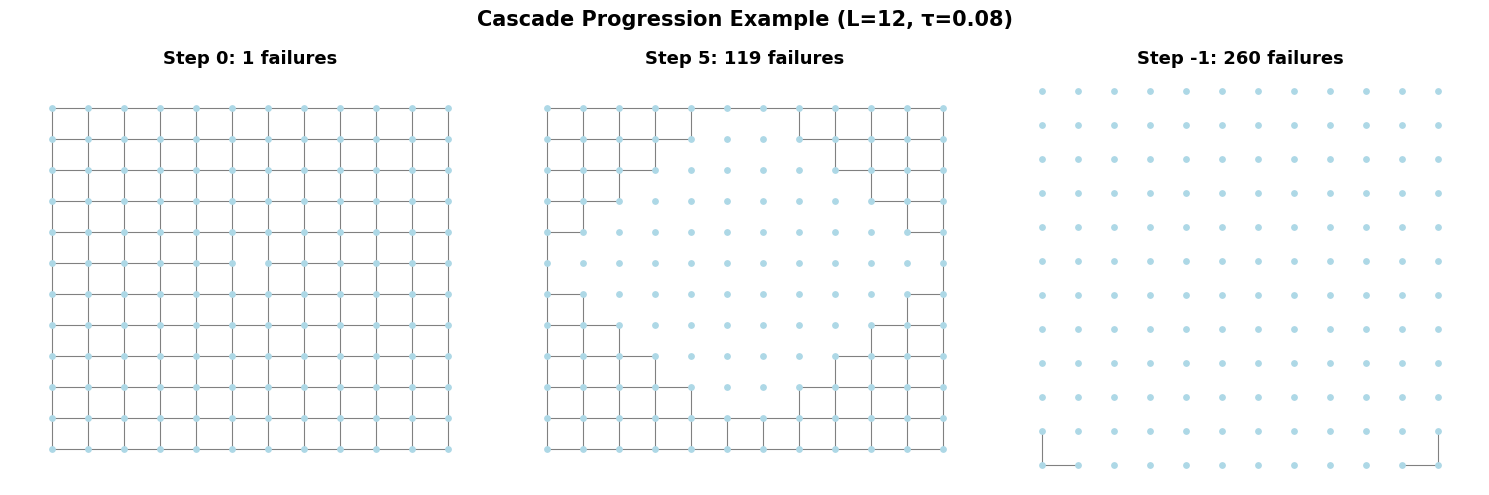

Results:
----------------------------------------------------------------------
L = 12:
  Critical tolerance: τ_c ≈ 0.190
  Giant component at τ_c: S = 0.338
  Survival probability: p = 0.332
  [Compare to 2D percolation: p_c = 0.5927]

L = 20:
  Critical tolerance: τ_c ≈ 0.190
  Giant component at τ_c: S = 0.335
  Survival probability: p = 0.333
  [Compare to 2D percolation: p_c = 0.5927]

L = 30:
  Critical tolerance: τ_c ≈ 0.250
  Giant component at τ_c: S = 0.667
  Survival probability: p = 0.666
  [Compare to 2D percolation: p_c = 0.5927]


Timing summary:
L=12: 3.11 seconds
L=20: 14.25 seconds
L=30: 43.95 seconds


In [5]:
if __name__ == "__main__":
    print("="*70)
    print("POWER GRID CASCADING FAILURES")
    print("="*70)
    print()
    
    # Params
    L_values = [12, 20, 30] 
    tolerances = np.linspace(0.1, 0.7, 21) 
    n_trials = 15
    
    print(f"Grid sizes: {L_values}")
    print(f"Tolerance points: {len(tolerances)}")
    print(f"Trials per point: {n_trials}")
    print(f"Total simulations: {len(L_values) * len(tolerances) * n_trials}")
    print()
    
    # Run simulations
    all_results = {}
    L_times = {}
    for L in L_values:
        start = time.perf_counter()
        all_results[L] = run_simulations(L, tolerances, n_trials)
        end = time.perf_counter()
        elapsed = end-start
        L_times[L] = elapsed
        print(f"\nTime for L={L}: {elapsed:.2f} seconds")
    
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    # Create all plots
    plot_all_results(all_results)
    plot_example_cascade(L=12, tolerance=0.08)
    
    # Print findings
    print("Results:")
    print("-" * 70)
    for L in L_values:
        results = all_results[L]
        tolerances_list = sorted(results.keys())
        
        # Estimate critical tol
        S_values = [np.mean([r['giant_fraction'] for r in results[t]]) 
                   for t in tolerances_list]
        idx_critical = np.argmin(np.abs(np.array(S_values) - 0.5))
        tau_c = tolerances_list[idx_critical]
        S_c = S_values[idx_critical]
        p_c = np.mean([r['survival_prob'] for r in results[tau_c]])
        
        print(f"L = {L}:")
        print(f"  Critical tolerance: τ_c ≈ {tau_c:.3f}")
        print(f"  Giant component at τ_c: S = {S_c:.3f}")
        print(f"  Survival probability: p = {p_c:.3f}")
        print(f"  [Compare to 2D percolation: p_c = 0.5927]")
        print()

    print("\nTiming summary:")
    for L, t in L_times.items():
        print(f"L={L}: {t:.2f} seconds")